# 13 — NLP Review Analysis

## Objective

This notebook analyzes written customer feedback using transparent natural-language processing techniques, including text preparation, word and phrase frequency, TF-IDF comparison, and review-length patterns.

The analysis uses review scores to define satisfaction groups and examines language associated with those groups. It does not assume that every word has a fixed sentiment or that frequently mentioned topics caused the customer’s rating.

## 1. Data Loading

Load the cleaned review data and order-level analytical table, then verify the availability of written feedback and valid review scores.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata

from collections import Counter
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images/notebook_outputs")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

reviews = pd.read_csv(
    DATA_DIR / "reviews_clean.csv",
    parse_dates=[
        "review_creation_date",
        "review_answer_timestamp"
    ]
)

order_analytics = pd.read_csv(
    DATA_DIR / "order_analytics.csv",
    parse_dates=["order_purchase_timestamp"]
)

review_summary = pd.DataFrame({
    "metric": [
        "Review records",
        "Orders represented",
        "Valid review scores",
        "Reviews with a title",
        "Reviews with a message",
        "Reviews with any written feedback"
    ],
    "value": [
        len(reviews),
        reviews["order_id"].nunique(),
        reviews["review_score"].between(1, 5).sum(),
        reviews["review_comment_title"].notna().sum(),
        reviews["review_comment_message"].notna().sum(),
        reviews["has_written_feedback"].sum()
    ]
})

display(
    review_summary.style.format({
        "value": "{:,.0f}"
    })
)

print(
    "Written-feedback coverage:",
    f"{reviews['has_written_feedback'].mean():.2%}"
)

,metric,value
0,Review records,"99,224"
1,Orders represented,"98,673"
2,Valid review scores,"99,224"
3,Reviews with a title,"11,568"
4,Reviews with a message,"40,977"
5,Reviews with any written feedback,"42,706"


Written-feedback coverage: 43.04%


## 2. Written-Review Corpus

Combine available review titles and messages into one text field, assign score-based satisfaction groups, and measure text length while retaining one row per review record.

In [3]:
title_text = (
    reviews["review_comment_title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

message_text = (
    reviews["review_comment_message"]
    .fillna("")
    .astype(str)
    .str.strip()
)

actual_written_text = (
    title_text.ne("")
    | message_text.ne("")
)

flagged_but_empty = (
    reviews["has_written_feedback"]
    & ~actual_written_text
).sum()

written_reviews = (
    reviews.loc[actual_written_text]
    .copy()
)

written_reviews["review_title_text"] = (
    title_text.loc[actual_written_text]
)

written_reviews["review_message_text"] = (
    message_text.loc[actual_written_text]
)

written_reviews["review_text_raw"] = (
    written_reviews["review_title_text"]
    + " "
    + written_reviews["review_message_text"]
).str.strip()

written_reviews["satisfaction_group"] = np.select(
    [
        written_reviews["review_score"] <= 2,
        written_reviews["review_score"] == 3
    ],
    [
        "Low satisfaction (1–2)",
        "Neutral (3)"
    ],
    default="High satisfaction (4–5)"
)

written_reviews["character_count"] = (
    written_reviews["review_text_raw"]
    .str.len()
)

written_reviews["word_count"] = (
    written_reviews["review_text_raw"]
    .str.findall(r"\b\w+\b")
    .str.len()
)

corpus_validation = pd.DataFrame([
    {
        "validation_check":
            "Actual non-empty written reviews represented",
        "result": len(written_reviews),
        "expected": int(actual_written_text.sum())
    },
    {
        "validation_check":
            "Empty texts in final corpus",
        "result": (
            written_reviews["review_text_raw"]
            .str.len() == 0
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Invalid review scores",
        "result": (
            ~written_reviews["review_score"]
            .between(1, 5)
        ).sum(),
        "expected": 0
    }
])

corpus_validation["status"] = np.where(
    corpus_validation["result"]
    == corpus_validation["expected"],
    "Passed",
    "Failed"
)

display(corpus_validation)

print(
    "Metadata-flagged reviews excluded as empty:",
    f"{flagged_but_empty:,}"
)

corpus_profile = (
    written_reviews
    .groupby("satisfaction_group", as_index=False)
    .agg(
        written_reviews=("review_id", "count"),
        average_character_count=(
            "character_count",
            "mean"
        ),
        median_character_count=(
            "character_count",
            "median"
        ),
        average_word_count=("word_count", "mean"),
        median_word_count=("word_count", "median")
    )
)

corpus_profile["written_review_share"] = (
    corpus_profile["written_reviews"]
    / corpus_profile["written_reviews"].sum()
)

display(
    corpus_profile.style.format({
        "written_reviews": "{:,.0f}",
        "average_character_count": "{:,.1f}",
        "median_character_count": "{:,.1f}",
        "average_word_count": "{:,.1f}",
        "median_word_count": "{:,.1f}",
        "written_review_share": "{:.2%}"
    })
)

,validation_check,result,expected,status
0,Actual non-empty written reviews represented,42687,42687,Passed
1,Empty texts in final corpus,0,0,Passed
2,Invalid review scores,0,0,Passed


Metadata-flagged reviews excluded as empty: 19


,satisfaction_group,written_reviews,average_character_count,median_character_count,average_word_count,median_word_count,written_review_share
0,High satisfaction (4–5),"28,050",54.3,43.0,9.0,7.0,65.71%
1,Low satisfaction (1–2),"10,994",101.6,91.0,17.9,16.0,25.75%
2,Neutral (3),"3,643",84.1,71.0,14.8,13.0,8.53%


***Observation:*** Low-satisfaction reviews are substantially longer, averaging 17.9 words compared with 9.0 words for high-satisfaction reviews. This indicates that dissatisfied customers provide more detailed written feedback on average, although text length alone does not identify the topic or cause of dissatisfaction.

## 3. Portuguese Text Preparation

Normalize case, spacing, URLs, numbers, and punctuation, then remove common Portuguese function words while preserving meaningful terms such as “não,” product, delivery, and service-related vocabulary.

In [6]:
portuguese_stopwords = {
    "a", "à", "ao", "aos", "as", "às",
    "o", "os", "um", "uma", "uns", "umas",
    "de", "da", "das", "do", "dos",
    "em", "na", "nas", "no", "nos",
    "por", "para", "com", "sem", "sob",
    "sobre", "entre", "até", "após",
    "e", "ou", "mas", "porque", "que",
    "se", "como", "quando", "onde",
    "qual", "quais", "quem",
    "me", "te", "nos", "lhe", "lhes",
    "meu", "minha", "meus", "minhas",
    "seu", "sua", "seus", "suas",
    "este", "esta", "estes", "estas",
    "esse", "essa", "esses", "essas",
    "aquele", "aquela", "aqueles", "aquelas",
    "isso", "isto", "aquilo",
    "ele", "ela", "eles", "elas",
    "eu", "tu", "nós", "vocês",
    "ser", "estar", "ter", "foi", "era",
    "são", "está", "estava", "tem",
    "tinha", "há", "já", "mais", "muito",
    "muita", "muitos", "muitas", "também",
    "só", "mesmo", "bem", "todo", "toda",
    "todos", "todas", "pelo", "pela",
    "pelos", "pelas", "num", "numa",
    "ainda", "então", "assim", "aí"
}


def remove_accents(text):
    return "".join(
        character
        for character in unicodedata.normalize(
            "NFKD",
            text
        )
        if not unicodedata.combining(character)
    )


normalized_stopwords = {
    remove_accents(word.lower())
    for word in portuguese_stopwords
}


def normalize_review_text(text):
    text = unicodedata.normalize(
        "NFKC",
        str(text).lower()
    )

    text = remove_accents(text)

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    text = re.sub(
        r"\d+",
        " ",
        text
    )

    text = re.sub(
        r"[^\w\s]",
        " ",
        text
    )

    text = text.replace("_", " ")

    tokens = [
        token
        for token in text.split()
        if (
            len(token) > 2
            and token not in normalized_stopwords
        )
    ]

    return " ".join(tokens)


written_reviews["clean_review_text"] = (
    written_reviews["review_text_raw"]
    .apply(normalize_review_text)
)

written_reviews["clean_tokens"] = (
    written_reviews["clean_review_text"]
    .str.split()
)

written_reviews["clean_token_count"] = (
    written_reviews["clean_tokens"]
    .str.len()
)

nlp_reviews = (
    written_reviews.loc[
        written_reviews[
            "clean_review_text"
        ].str.len() > 0
    ]
    .copy()
)

text_preparation_validation = pd.DataFrame([
    {
        "validation_check":
            "NLP reviews exceeding written corpus",
        "result": int(
            len(nlp_reviews)
            > len(written_reviews)
        ),
        "expected": 0
    },
    {
        "validation_check":
            "Empty texts in NLP corpus",
        "result": (
            nlp_reviews[
                "clean_review_text"
            ].str.len() == 0
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Missing satisfaction groups",
        "result": nlp_reviews[
            "satisfaction_group"
        ].isna().sum(),
        "expected": 0
    }
])

text_preparation_validation["status"] = np.where(
    text_preparation_validation["result"]
    == text_preparation_validation["expected"],
    "Passed",
    "Failed"
)

display(text_preparation_validation)

print(
    "Written reviews before text preparation:",
    f"{len(written_reviews):,}"
)
print(
    "Reviews retained for term analysis:",
    f"{len(nlp_reviews):,}"
)
print(
    "Reviews empty after stop-word removal:",
    f"{len(written_reviews) - len(nlp_reviews):,}"
)

,validation_check,result,expected,status
0,NLP reviews exceeding written corpus,0,0,Passed
1,Empty texts in NLP corpus,0,0,Passed
2,Missing satisfaction groups,0,0,Passed


Written reviews before text preparation: 42,687
Reviews retained for term analysis: 42,252
Reviews empty after stop-word removal: 435


***Observation:*** Text preparation retained 42,252 reviews for term analysis. A further 435 reviews contained only short tokens or removed function words, so they remain available for review-length analysis but are excluded from word and phrase frequency calculations.

## 4. Frequent Terms by Satisfaction Group

Calculate both total term frequency and the share of reviews containing each term, allowing common vocabulary to be compared across low-, neutral-, and high-satisfaction feedback.

In [7]:
nlp_reviews["review_record_key"] = (
    nlp_reviews["review_id"].astype(str)
    + "|"
    + nlp_reviews["order_id"].astype(str)
)

token_occurrences = (
    nlp_reviews[
        [
            "review_record_key",
            "satisfaction_group",
            "clean_tokens"
        ]
    ]
    .explode("clean_tokens")
    .rename(
        columns={
            "clean_tokens": "term"
        }
    )
)

group_review_counts = (
    nlp_reviews
    .groupby("satisfaction_group")[
        "review_record_key"
    ]
    .nunique()
    .rename("group_reviews")
    .reset_index()
)

term_summary = (
    token_occurrences
    .groupby(
        [
            "satisfaction_group",
            "term"
        ],
        as_index=False
    )
    .agg(
        term_occurrences=(
            "review_record_key",
            "size"
        ),
        reviews_containing_term=(
            "review_record_key",
            "nunique"
        )
    )
    .merge(
        group_review_counts,
        on="satisfaction_group",
        how="left",
        validate="many_to_one"
    )
)

term_summary["review_share"] = (
    term_summary["reviews_containing_term"]
    / term_summary["group_reviews"]
)

top_terms_by_group = (
    term_summary
    .sort_values(
        [
            "satisfaction_group",
            "review_share",
            "term_occurrences"
        ],
        ascending=[True, False, False]
    )
    .groupby(
        "satisfaction_group",
        group_keys=False
    )
    .head(12)
    .reset_index(drop=True)
)

for satisfaction_group in [
    "Low satisfaction (1–2)",
    "Neutral (3)",
    "High satisfaction (4–5)"
]:
    print(satisfaction_group)

    display(
        top_terms_by_group.loc[
            top_terms_by_group[
                "satisfaction_group"
            ] == satisfaction_group,
            [
                "term",
                "term_occurrences",
                "reviews_containing_term",
                "review_share"
            ]
        ]
        .reset_index(drop=True)
        .style.format({
            "term_occurrences": "{:,.0f}",
            "reviews_containing_term": "{:,.0f}",
            "review_share": "{:.2%}"
        })
    )

print(
    "Token occurrences represented:",
    f"{len(token_occurrences):,}"
)
print(
    "Expected token occurrences:",
    f"{nlp_reviews['clean_token_count'].sum():,}"
)

Low satisfaction (1–2)


,term,term_occurrences,reviews_containing_term,review_share
0,nao,"9,140","6,636",60.50%
1,produto,"6,829","5,605",51.10%
2,recebi,"3,503","3,125",28.49%
3,comprei,"1,900","1,800",16.41%
4,entrega,"1,561","1,417",12.92%
5,veio,"1,618","1,398",12.75%
6,entregue,"1,437","1,298",11.83%
7,chegou,"1,241","1,141",10.40%
8,estou,971,928,8.46%
9,prazo,936,871,7.94%


Neutral (3)


,term,term_occurrences,reviews_containing_term,review_share
0,produto,"1,733","1,464",40.58%
1,nao,"1,634","1,280",35.48%
2,recebi,574,515,14.27%
3,entrega,536,494,13.69%
4,veio,552,492,13.64%
5,bom,518,478,13.25%
6,prazo,495,466,12.92%
7,chegou,371,346,9.59%
8,porem,336,329,9.12%
9,comprei,298,289,8.01%


High satisfaction (4–5)


,term,term_occurrences,reviews_containing_term,review_share
0,produto,"11,158","10,376",37.49%
1,prazo,"7,194","7,066",25.53%
2,recomendo,"5,661","5,465",19.75%
3,antes,"5,343","5,290",19.11%
4,bom,"5,162","4,834",17.47%
5,entrega,"4,972","4,798",17.34%
6,chegou,"4,067","3,955",14.29%
7,otimo,"3,464","3,277",11.84%
8,super,"2,517","2,365",8.55%
9,excelente,"2,426","2,287",8.26%


Token occurrences represented: 306,903
Expected token occurrences: 306,903


***Observation:*** After accent normalization, `nao` appears in 60.50% of low-satisfaction reviews compared with 35.48% of neutral reviews, while high-satisfaction feedback more frequently contains terms such as `recomendo`, `otimo`, and `excelente`. Individual words lack context, so phrase-level analysis is required before interpreting the topics being discussed.

## 5. Frequent Phrases by Satisfaction Group

Analyze two-word phrases to preserve more context than isolated term counts and identify recurring expressions associated with each score-based satisfaction group.

In [8]:
from sklearn.feature_extraction.text import (
    CountVectorizer
)

bigram_tables = []

for satisfaction_group in [
    "Low satisfaction (1–2)",
    "Neutral (3)",
    "High satisfaction (4–5)"
]:
    group_reviews = nlp_reviews.loc[
        nlp_reviews["satisfaction_group"]
        == satisfaction_group,
        "clean_review_text"
    ]

    bigram_vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        min_df=5
    )

    bigram_matrix = (
        bigram_vectorizer
        .fit_transform(group_reviews)
    )

    bigram_terms = (
        bigram_vectorizer
        .get_feature_names_out()
    )

    bigram_occurrences = np.asarray(
        bigram_matrix.sum(axis=0)
    ).ravel()

    bigram_review_counts = np.asarray(
        (bigram_matrix > 0).sum(axis=0)
    ).ravel()

    group_bigram_summary = pd.DataFrame({
        "satisfaction_group": satisfaction_group,
        "phrase": bigram_terms,
        "phrase_occurrences": bigram_occurrences,
        "reviews_containing_phrase":
            bigram_review_counts
    })

    group_bigram_summary["group_reviews"] = (
        len(group_reviews)
    )

    group_bigram_summary["review_share"] = (
        group_bigram_summary[
            "reviews_containing_phrase"
        ]
        / group_bigram_summary["group_reviews"]
    )

    bigram_tables.append(
        group_bigram_summary
    )

bigram_summary = pd.concat(
    bigram_tables,
    ignore_index=True
)

top_bigrams_by_group = (
    bigram_summary
    .sort_values(
        [
            "satisfaction_group",
            "review_share",
            "phrase_occurrences"
        ],
        ascending=[True, False, False]
    )
    .groupby(
        "satisfaction_group",
        group_keys=False
    )
    .head(12)
    .reset_index(drop=True)
)

for satisfaction_group in [
    "Low satisfaction (1–2)",
    "Neutral (3)",
    "High satisfaction (4–5)"
]:
    print(satisfaction_group)

    display(
        top_bigrams_by_group.loc[
            top_bigrams_by_group[
                "satisfaction_group"
            ] == satisfaction_group,
            [
                "phrase",
                "phrase_occurrences",
                "reviews_containing_phrase",
                "review_share"
            ]
        ]
        .reset_index(drop=True)
        .style.format({
            "phrase_occurrences": "{:,.0f}",
            "reviews_containing_phrase": "{:,.0f}",
            "review_share": "{:.2%}"
        })
    )

print(
    "Satisfaction groups analyzed:",
    bigram_summary[
        "satisfaction_group"
    ].nunique()
)

Low satisfaction (1–2)


,phrase,phrase_occurrences,reviews_containing_phrase,review_share
0,nao recebi,"2,022","1,904",17.36%
1,recebi produto,"1,334","1,287",11.73%
2,produto nao,"1,262","1,187",10.82%
3,nao entregue,648,609,5.55%
4,nao chegou,601,570,5.20%
5,nao recomendo,459,453,4.13%
6,produto veio,354,341,3.11%
7,estou aguardando,311,310,2.83%
8,agora nao,262,259,2.36%
9,nota fiscal,260,251,2.29%


Neutral (3)


,phrase,phrase_occurrences,reviews_containing_phrase,review_share
0,nao recebi,194,186,5.16%
1,recebi produto,166,164,4.55%
2,produto nao,163,161,4.46%
3,produto bom,107,105,2.91%
4,produto chegou,100,97,2.69%
5,antes prazo,97,96,2.66%
6,produto veio,96,93,2.58%
7,produto entregue,91,89,2.47%
8,dentro prazo,86,84,2.33%
9,nao veio,81,79,2.19%


High satisfaction (4–5)


,phrase,phrase_occurrences,reviews_containing_phrase,review_share
0,antes prazo,"4,077","4,057",14.66%
1,chegou antes,"1,889","1,882",6.80%
2,produto chegou,"1,296","1,290",4.66%
3,super recomendo,"1,269","1,248",4.51%
4,entrega rapida,"1,158","1,141",4.12%
5,produto entregue,"1,089","1,084",3.92%
6,otimo produto,969,961,3.47%
7,dentro prazo,926,924,3.34%
8,entregue antes,857,856,3.09%
9,produto bom,823,809,2.92%


Satisfaction groups analyzed: 3


***Observation:*** Low-satisfaction reviews frequently contain phrases related to non-receipt, including `nao recebi` in 17.36% of reviews and `nao entregue` in 5.55%. High-satisfaction reviews more frequently mention early or fast delivery, such as `antes prazo` in 14.66% and `entrega rapida` in 4.12%; these are textual associations rather than verified causes of the ratings.

## 6. TF-IDF Term Distinctiveness

Use TF-IDF across individual words and two-word phrases to identify vocabulary that is relatively more prominent in low- or high-satisfaction reviews, rather than simply selecting the most frequent terms overall.

In [9]:
from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

tfidf_reviews = (
    nlp_reviews.loc[
        nlp_reviews["satisfaction_group"].isin([
            "Low satisfaction (1–2)",
            "High satisfaction (4–5)"
        ])
    ]
    .copy()
)

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=20,
    max_df=0.85,
    sublinear_tf=True
)

tfidf_matrix = (
    tfidf_vectorizer
    .fit_transform(
        tfidf_reviews["clean_review_text"]
    )
)

tfidf_terms = (
    tfidf_vectorizer
    .get_feature_names_out()
)

low_mask = (
    tfidf_reviews["satisfaction_group"]
    == "Low satisfaction (1–2)"
).to_numpy()

high_mask = (
    tfidf_reviews["satisfaction_group"]
    == "High satisfaction (4–5)"
).to_numpy()

low_mean_tfidf = np.asarray(
    tfidf_matrix[low_mask].mean(axis=0)
).ravel()

high_mean_tfidf = np.asarray(
    tfidf_matrix[high_mask].mean(axis=0)
).ravel()

tfidf_comparison = pd.DataFrame({
    "term_or_phrase": tfidf_terms,
    "low_mean_tfidf": low_mean_tfidf,
    "high_mean_tfidf": high_mean_tfidf
})

tfidf_comparison["low_distinctiveness"] = (
    tfidf_comparison["low_mean_tfidf"]
    - tfidf_comparison["high_mean_tfidf"]
)

tfidf_comparison["high_distinctiveness"] = (
    tfidf_comparison["high_mean_tfidf"]
    - tfidf_comparison["low_mean_tfidf"]
)

low_distinctive_terms = (
    tfidf_comparison
    .nlargest(
        15,
        "low_distinctiveness"
    )
    [
        [
            "term_or_phrase",
            "low_mean_tfidf",
            "high_mean_tfidf",
            "low_distinctiveness"
        ]
    ]
    .reset_index(drop=True)
)

high_distinctive_terms = (
    tfidf_comparison
    .nlargest(
        15,
        "high_distinctiveness"
    )
    [
        [
            "term_or_phrase",
            "low_mean_tfidf",
            "high_mean_tfidf",
            "high_distinctiveness"
        ]
    ]
    .reset_index(drop=True)
)

print("Terms more distinctive of low satisfaction")
display(
    low_distinctive_terms.style.format({
        "low_mean_tfidf": "{:.4f}",
        "high_mean_tfidf": "{:.4f}",
        "low_distinctiveness": "{:.4f}"
    })
)

print("Terms more distinctive of high satisfaction")
display(
    high_distinctive_terms.style.format({
        "low_mean_tfidf": "{:.4f}",
        "high_mean_tfidf": "{:.4f}",
        "high_distinctiveness": "{:.4f}"
    })
)

print(
    "Reviews included in TF-IDF comparison:",
    f"{len(tfidf_reviews):,}"
)
print(
    "TF-IDF vocabulary size:",
    f"{len(tfidf_terms):,}"
)

Terms more distinctive of low satisfaction


,term_or_phrase,low_mean_tfidf,high_mean_tfidf,low_distinctiveness
0,nao,0.1060,0.0100,0.0960
1,recebi,0.0598,0.0110,0.0489
2,nao recebi,0.0493,0.0009,0.0484
3,recebi produto,0.0334,0.0046,0.0288
4,comprei,0.0321,0.0041,0.0281
5,produto nao,0.0292,0.0013,0.0279
6,veio,0.0271,0.0088,0.0183
7,nao entregue,0.0184,0.0004,0.0180
8,nao chegou,0.0166,0.0005,0.0161
9,pedido,0.0166,0.0036,0.0130


Terms more distinctive of high satisfaction


,term_or_phrase,low_mean_tfidf,high_mean_tfidf,high_distinctiveness
0,bom,0.0051,0.0698,0.0647
1,recomendo,0.0070,0.0560,0.0490
2,otimo,0.0010,0.0497,0.0488
3,antes,0.0024,0.0381,0.0357
4,prazo,0.0112,0.0454,0.0342
5,antes prazo,0.0011,0.0326,0.0315
6,excelente,0.0005,0.0315,0.0311
7,tudo,0.0020,0.0254,0.0234
8,super,0.0013,0.0237,0.0223
9,chegou antes,0.0004,0.0192,0.0187


Reviews included in TF-IDF comparison: 38,644
TF-IDF vocabulary size: 2,295


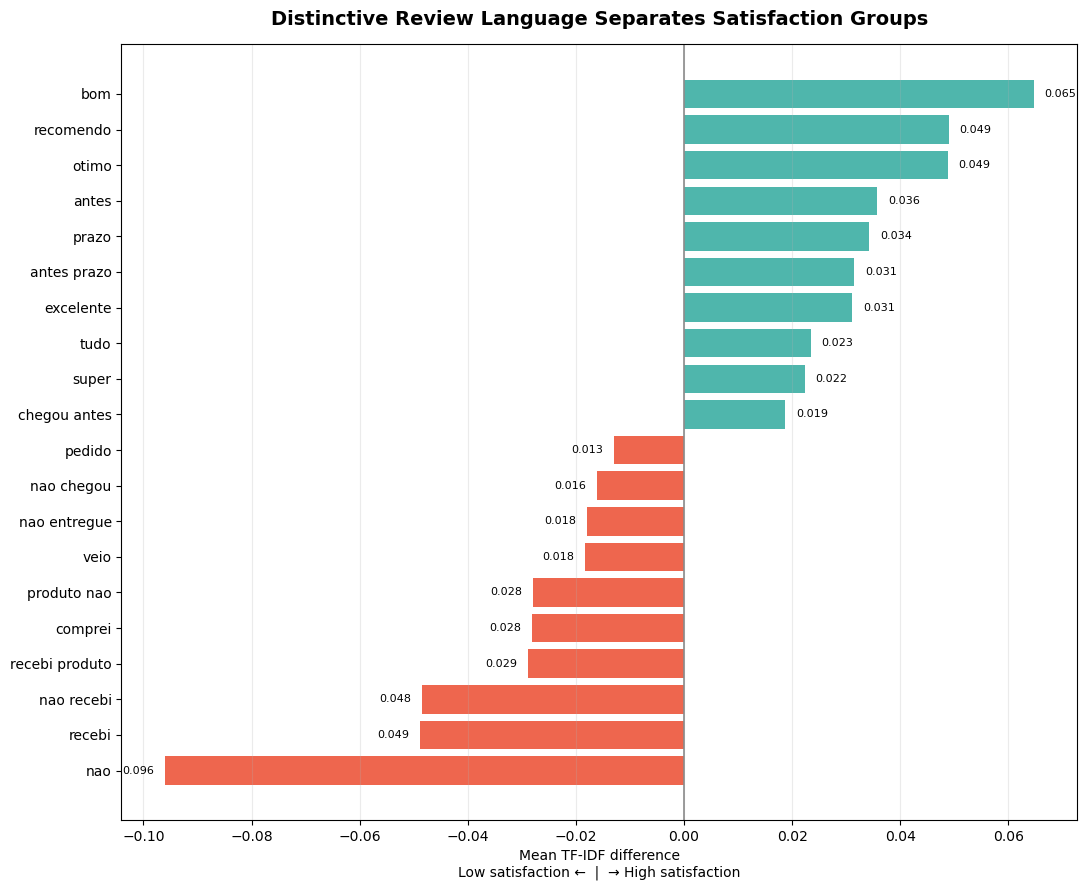

In [10]:
low_plot = (
    low_distinctive_terms
    .head(10)
    .copy()
)

low_plot["plot_value"] = (
    -low_plot["low_distinctiveness"]
)

low_plot["direction"] = "Low satisfaction"

high_plot = (
    high_distinctive_terms
    .head(10)
    .copy()
)

high_plot["plot_value"] = (
    high_plot["high_distinctiveness"]
)

high_plot["direction"] = "High satisfaction"

distinctive_plot = (
    pd.concat(
        [
            low_plot[
                [
                    "term_or_phrase",
                    "plot_value",
                    "direction"
                ]
            ],
            high_plot[
                [
                    "term_or_phrase",
                    "plot_value",
                    "direction"
                ]
            ]
        ],
        ignore_index=True
    )
    .sort_values("plot_value")
    .reset_index(drop=True)
)

bar_colors = distinctive_plot["direction"].map({
    "Low satisfaction": COLORS["negative"],
    "High satisfaction": COLORS["positive"]
})

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(
    distinctive_plot["term_or_phrase"],
    distinctive_plot["plot_value"],
    color=bar_colors,
    alpha=0.9
)

ax.axvline(
    0,
    color=COLORS["neutral"],
    linewidth=1.2
)

for bar, value in zip(
    bars,
    distinctive_plot["plot_value"]
):
    ax.text(
        value + (
            0.002 if value >= 0 else -0.002
        ),
        bar.get_y() + bar.get_height() / 2,
        f"{abs(value):.3f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=8
    )

ax.set_xlabel(
    "Mean TF-IDF difference\n"
    "Low satisfaction ←  |  → High satisfaction"
)
ax.set_ylabel("")

ax.set_title(
    "Distinctive Review Language Separates Satisfaction Groups",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "distinctive_review_language.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** TF-IDF differences show that non-receipt and negative-response language is relatively more prominent in low-satisfaction reviews, while recommendation and positive delivery language is more prominent in high-satisfaction reviews. These terms describe group-level textual patterns and should not be interpreted as a standalone sentiment classifier.

## 7. Rule-Based Review Themes

Use transparent Portuguese keyword and phrase dictionaries to identify recurring review themes. Reviews may contain multiple themes, and the resulting flags indicate textual mentions rather than verified operational incidents.

In [11]:
theme_patterns = {
    "Non-receipt": [
        "nao recebi",
        "nao chegou",
        "nao entregue",
        "estou aguardando",
        "aguardando produto",
        "pedido nao chegou"
    ],
    "Delivery timing": [
        "antes prazo",
        "dentro prazo",
        "entrega rapida",
        "chegou antes",
        "entregue antes",
        "atrasado",
        "atraso",
        "demorou",
        "prazo entrega"
    ],
    "Product quality or condition": [
        "qualidade",
        "defeito",
        "defeituoso",
        "quebrado",
        "danificado",
        "avariado",
        "produto bom",
        "otimo produto",
        "excelente produto"
    ],
    "Incorrect or incomplete item": [
        "produto errado",
        "veio errado",
        "item errado",
        "faltando",
        "incompleto",
        "nao veio",
        "recebi outro"
    ],
    "Service, return or refund": [
        "atendimento",
        "reembolso",
        "devolucao",
        "devolver",
        "troca",
        "cancelamento",
        "estorno"
    ]
}

theme_columns = []

for theme, patterns in theme_patterns.items():
    column_name = (
        "theme_"
        + re.sub(
            r"[^a-z0-9]+",
            "_",
            remove_accents(theme.lower())
        ).strip("_")
    )

    pattern_expression = "|".join(
        re.escape(pattern)
        for pattern in patterns
    )

    nlp_reviews[column_name] = (
        nlp_reviews["clean_review_text"]
        .str.contains(
            pattern_expression,
            regex=True,
            na=False
        )
    )

    theme_columns.append(column_name)

theme_labels = {
    (
        "theme_"
        + re.sub(
            r"[^a-z0-9]+",
            "_",
            remove_accents(theme.lower())
        ).strip("_")
    ): theme
    for theme in theme_patterns
}

theme_long = (
    nlp_reviews[
        [
            "review_record_key",
            "satisfaction_group"
        ]
        + theme_columns
    ]
    .melt(
        id_vars=[
            "review_record_key",
            "satisfaction_group"
        ],
        value_vars=theme_columns,
        var_name="theme_column",
        value_name="theme_mentioned"
    )
)

theme_long["theme"] = (
    theme_long["theme_column"]
    .map(theme_labels)
)

theme_summary = (
    theme_long
    .groupby(
        [
            "satisfaction_group",
            "theme"
        ],
        as_index=False
    )
    .agg(
        group_reviews=(
            "review_record_key",
            "nunique"
        ),
        reviews_mentioning_theme=(
            "theme_mentioned",
            "sum"
        )
    )
)

theme_summary["theme_review_share"] = (
    theme_summary[
        "reviews_mentioning_theme"
    ]
    / theme_summary["group_reviews"]
)

theme_summary = (
    theme_summary
    .sort_values(
        [
            "satisfaction_group",
            "theme_review_share"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    theme_summary.style.format({
        "group_reviews": "{:,.0f}",
        "reviews_mentioning_theme": "{:,.0f}",
        "theme_review_share": "{:.2%}"
    })
)

nlp_reviews["identified_theme_count"] = (
    nlp_reviews[theme_columns]
    .sum(axis=1)
)

print(
    "Reviews with at least one identified theme:",
    f"{(nlp_reviews['identified_theme_count'] > 0).sum():,}"
)
print(
    "Theme coverage:",
    f"{(nlp_reviews['identified_theme_count'] > 0).mean():.2%}"
)
print(
    "Reviews with multiple identified themes:",
    f"{(nlp_reviews['identified_theme_count'] > 1).sum():,}"
)

,satisfaction_group,theme,group_reviews,reviews_mentioning_theme,theme_review_share
0,High satisfaction (4–5),Delivery timing,"27,675","7,110",25.69%
1,High satisfaction (4–5),Product quality or condition,"27,675","4,271",15.43%
2,High satisfaction (4–5),"Service, return or refund","27,675",797,2.88%
3,High satisfaction (4–5),Non-receipt,"27,675",214,0.77%
4,High satisfaction (4–5),Incorrect or incomplete item,"27,675",138,0.50%
5,Low satisfaction (1–2),Non-receipt,"10,969","3,304",30.12%
6,Low satisfaction (1–2),"Service, return or refund","10,969","1,181",10.77%
7,Low satisfaction (1–2),Product quality or condition,"10,969",935,8.52%
8,Low satisfaction (1–2),Incorrect or incomplete item,"10,969",782,7.13%
9,Low satisfaction (1–2),Delivery timing,"10,969",770,7.02%


Reviews with at least one identified theme: 18,325
Theme coverage: 43.37%
Reviews with multiple identified themes: 2,677


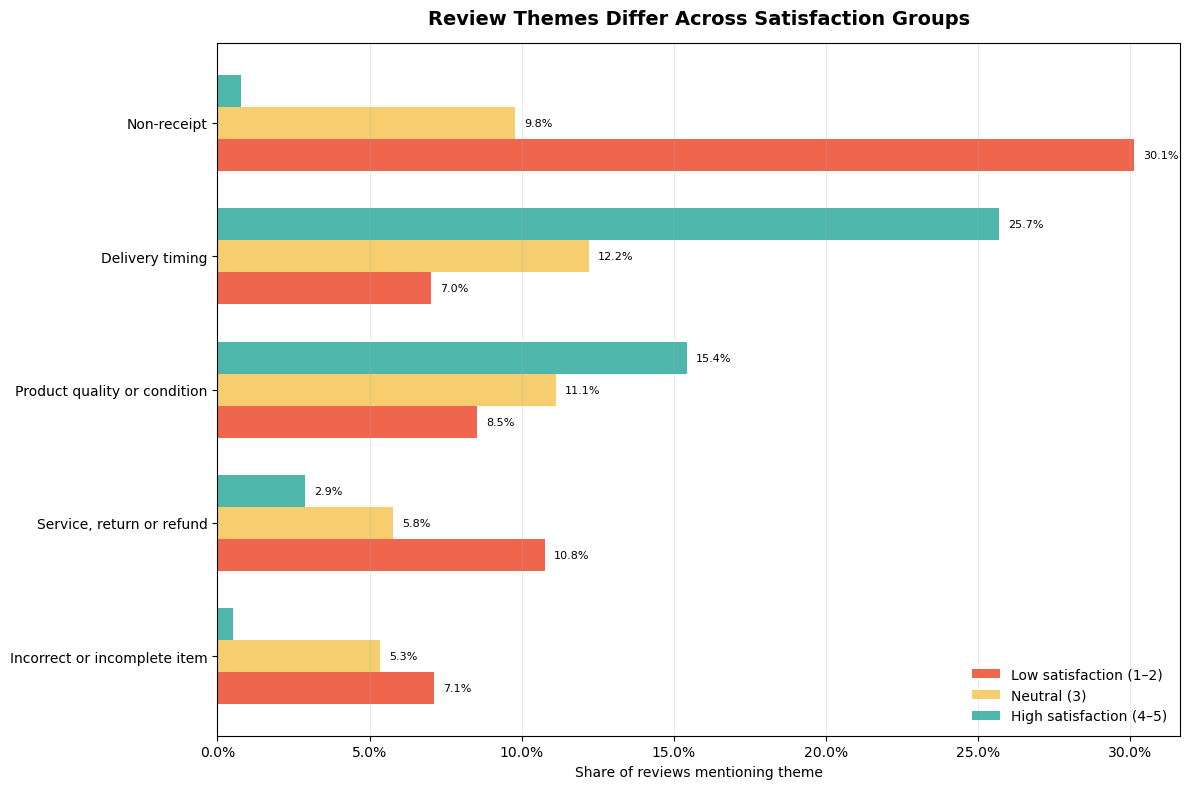

In [12]:
theme_plot = (
    theme_summary
    .pivot(
        index="theme",
        columns="satisfaction_group",
        values="theme_review_share"
    )
    .fillna(0)
)

theme_order = (
    theme_plot.max(axis=1)
    .sort_values()
    .index
)

theme_plot = theme_plot.loc[
    theme_order
]

group_order = [
    "Low satisfaction (1–2)",
    "Neutral (3)",
    "High satisfaction (4–5)"
]

theme_plot = theme_plot[
    group_order
]

positions = np.arange(
    len(theme_plot)
)

bar_height = 0.24

fig, ax = plt.subplots(figsize=(12, 8))

group_colors = {
    "Low satisfaction (1–2)":
        COLORS["negative"],
    "Neutral (3)":
        COLORS["accent"],
    "High satisfaction (4–5)":
        COLORS["positive"]
}

for group_index, group in enumerate(
    group_order
):
    offset = (
        group_index - 1
    ) * bar_height

    bars = ax.barh(
        positions + offset,
        theme_plot[group],
        height=bar_height,
        color=group_colors[group],
        alpha=0.9,
        label=group
    )

    for bar, value in zip(
        bars,
        theme_plot[group]
    ):
        if value > 0.015:
            ax.text(
                value + 0.003,
                bar.get_y()
                + bar.get_height() / 2,
                f"{value:.1%}",
                va="center",
                fontsize=8
            )

ax.set_yticks(positions)
ax.set_yticklabels(
    theme_plot.index
)

ax.xaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.set_xlabel(
    "Share of reviews mentioning theme"
)
ax.set_ylabel("")

ax.set_title(
    "Review Themes Differ Across Satisfaction Groups",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "review_themes_by_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Non-receipt and service, return, or refund language is substantially more prevalent in low-satisfaction feedback, while high-satisfaction reviews more frequently mention delivery timing and product quality in positive contexts. Reviews may contain multiple themes, and dictionary matches indicate textual mentions rather than verified operational events.

## 8. Operational Context for Non-Receipt Language

Connect reviews mentioning non-receipt with order status and delivery measures to determine where this language appears, while recognizing that order records may have been updated after a review was submitted.

In [13]:
review_context = (
    nlp_reviews
    .merge(
        order_analytics[
            [
                "order_id",
                "order_status",
                "has_valid_delivery_metric",
                "late_delivery_flag_numeric",
                "delivery_days"
            ]
        ],
        on="order_id",
        how="left",
        validate="many_to_one"
    )
)

review_context["is_non_receipt_theme"] = (
    review_context["theme_non_receipt"]
)

review_context["is_delivered_order"] = (
    review_context["order_status"]
    == "delivered"
)

review_context["late_delivery_for_context"] = (
    pd.to_numeric(
        review_context[
            "late_delivery_flag_numeric"
        ],
        errors="coerce"
    )
    .where(
        review_context[
            "has_valid_delivery_metric"
        ]
    )
)

non_receipt_reviews = (
    review_context.loc[
        review_context["is_non_receipt_theme"]
    ]
    .copy()
)

non_receipt_status_summary = (
    non_receipt_reviews
    .groupby("order_status", as_index=False)
    .agg(
        reviews=("review_record_key", "nunique"),
        average_review_score=(
            "review_score",
            "mean"
        ),
        valid_delivery_records=(
            "late_delivery_for_context",
            "count"
        ),
        late_delivery_rate=(
            "late_delivery_for_context",
            "mean"
        ),
        average_delivery_days=(
            "delivery_days",
            "mean"
        )
    )
)

non_receipt_status_summary["review_share"] = (
    non_receipt_status_summary["reviews"]
    / non_receipt_status_summary["reviews"].sum()
)

non_receipt_status_summary = (
    non_receipt_status_summary
    .sort_values(
        "reviews",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    non_receipt_status_summary.style.format({
        "reviews": "{:,.0f}",
        "average_review_score": "{:.2f}",
        "valid_delivery_records": "{:,.0f}",
        "late_delivery_rate": "{:.2%}",
        "average_delivery_days": "{:.2f}",
        "review_share": "{:.2%}"
    })
)

theme_context_summary = (
    review_context
    .assign(
        review_group=np.where(
            review_context[
                "is_non_receipt_theme"
            ],
            "Mentions non-receipt",
            "Other written reviews"
        )
    )
    .groupby("review_group", as_index=False)
    .agg(
        reviews=("review_record_key", "nunique"),
        average_review_score=(
            "review_score",
            "mean"
        ),
        low_satisfaction_rate=(
            "review_score",
            lambda values:
                values.le(2).mean()
        ),
        delivered_order_rate=(
            "is_delivered_order",
            "mean"
        ),
        valid_delivery_records=(
            "late_delivery_for_context",
            "count"
        ),
        late_delivery_rate=(
            "late_delivery_for_context",
            "mean"
        ),
        average_delivery_days=(
            "delivery_days",
            "mean"
        )
    )
)

display(
    theme_context_summary.style.format({
        "reviews": "{:,.0f}",
        "average_review_score": "{:.2f}",
        "low_satisfaction_rate": "{:.2%}",
        "delivered_order_rate": "{:.2%}",
        "valid_delivery_records": "{:,.0f}",
        "late_delivery_rate": "{:.2%}",
        "average_delivery_days": "{:.2f}"
    })
)

print(
    "Non-receipt reviews represented:",
    f"{len(non_receipt_reviews):,}"
)

,order_status,reviews,average_review_score,valid_delivery_records,late_delivery_rate,average_delivery_days,review_share
0,delivered,"3,093",1.52,"3,087",54.81%,25.64,79.90%
1,shipped,299,1.40,0,nan%,nan,7.72%
2,unavailable,148,1.22,0,nan%,nan,3.82%
3,canceled,129,1.22,0,nan%,nan,3.33%
4,invoiced,108,1.19,0,nan%,nan,2.79%
5,processing,93,1.24,0,nan%,nan,2.40%
6,created,1,1.00,0,nan%,nan,0.03%


,review_group,reviews,average_review_score,low_satisfaction_rate,delivered_order_rate,valid_delivery_records,late_delivery_rate,average_delivery_days
0,Mentions non-receipt,"3,871",1.48,85.35%,79.90%,"3,087",54.81%,25.64
1,Other written reviews,"38,381",3.92,19.97%,97.08%,"37,177",5.75%,12.37


Non-receipt reviews represented: 3,871


***Observation:*** Non-receipt language appears in 3,871 reviews, 85.35% of which have low satisfaction scores. Although 79.90% are currently associated with delivered orders, those valid delivered records have a 54.81% late-delivery rate and average delivery time of 25.64 days, suggesting that review timing and later order-status updates may affect interpretation.

## 9. Final Validation and Export Preparation

Confirm that the NLP corpus, tokens, phrases, TF-IDF inputs, themes, and order-context joins remain complete and internally consistent.

In [14]:
theme_group_review_total = (
    theme_summary
    .groupby("satisfaction_group")[
        "group_reviews"
    ]
    .first()
    .sum()
)

final_validation = pd.DataFrame([
    {
        "validation_check":
            "Actual written reviews represented",
        "result": len(written_reviews),
        "expected": 42_687
    },
    {
        "validation_check":
            "NLP corpus reviews represented",
        "result": len(nlp_reviews),
        "expected": 42_252
    },
    {
        "validation_check":
            "Duplicate review-record keys",
        "result": nlp_reviews[
            "review_record_key"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Token occurrences represented",
        "result": len(token_occurrences),
        "expected": int(
            nlp_reviews[
                "clean_token_count"
            ].sum()
        )
    },
    {
        "validation_check":
            "Satisfaction groups in phrase analysis",
        "result": bigram_summary[
            "satisfaction_group"
        ].nunique(),
        "expected": 3
    },
    {
        "validation_check":
            "TF-IDF reviews represented",
        "result": tfidf_matrix.shape[0],
        "expected": len(tfidf_reviews)
    },
    {
        "validation_check":
            "Theme-group reviews represented",
        "result": theme_group_review_total,
        "expected": len(nlp_reviews)
    },
    {
        "validation_check":
            "Invalid theme review shares",
        "result": (
            ~theme_summary[
                "theme_review_share"
            ].between(0, 1)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Review-context rows represented",
        "result": len(review_context),
        "expected": len(nlp_reviews)
    },
    {
        "validation_check":
            "Reviews missing order context",
        "result": review_context[
            "order_status"
        ].isna().sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Non-receipt reviews represented",
        "result": len(non_receipt_reviews),
        "expected": int(
            nlp_reviews[
                "theme_non_receipt"
            ].sum()
        )
    }
])

final_validation["status"] = np.where(
    final_validation["result"]
    == final_validation["expected"],
    "Passed",
    "Failed"
)

display(final_validation)

,validation_check,result,expected,status
0,Actual written reviews represented,42687,42687,Passed
1,NLP corpus reviews represented,42252,42252,Passed
2,Duplicate review-record keys,0,0,Passed
3,Token occurrences represented,306903,306903,Passed
4,Satisfaction groups in phrase analysis,3,3,Passed
5,TF-IDF reviews represented,38644,38644,Passed
6,Theme-group reviews represented,42252,42252,Passed
7,Invalid theme review shares,0,0,Passed
8,Review-context rows represented,42252,42252,Passed
9,Reviews missing order context,0,0,Passed


## 10. Export Analytical Outputs

Export the prepared review corpus, term and phrase summaries, TF-IDF comparisons, rule-based themes, operational context, and validation results for reporting and reproducibility.

In [15]:
theme_dictionary = pd.DataFrame([
    {
        "theme": theme,
        "pattern": pattern
    }
    for theme, patterns in theme_patterns.items()
    for pattern in patterns
])

nlp_export_columns = [
    "review_id",
    "order_id",
    "review_score",
    "satisfaction_group",
    "review_text_raw",
    "clean_review_text",
    "character_count",
    "word_count",
    "clean_token_count",
    "identified_theme_count"
] + theme_columns

review_nlp_corpus_export = (
    nlp_reviews[nlp_export_columns]
    .copy()
)

export_files = {
    "review_nlp_corpus.csv":
        review_nlp_corpus_export,
    "review_term_summary.csv":
        term_summary,
    "review_bigram_summary.csv":
        bigram_summary,
    "review_tfidf_comparison.csv":
        tfidf_comparison,
    "review_theme_summary.csv":
        theme_summary,
    "non_receipt_order_status_summary.csv":
        non_receipt_status_summary,
    "review_theme_context_summary.csv":
        theme_context_summary,
    "review_theme_dictionary.csv":
        theme_dictionary,
    "review_nlp_validation.csv":
        final_validation
}

for filename, dataframe in export_files.items():
    dataframe.to_csv(
        DATA_DIR / filename,
        index=False
    )

all_files_created = all(
    (DATA_DIR / filename).exists()
    for filename in export_files
)

print(
    "NLP-analysis files exported:",
    len(export_files)
)
print(
    "All NLP-analysis files created:",
    all_files_created
)

NLP-analysis files exported: 9
All NLP-analysis files created: True


## Conclusion

***Key findings:***

- The source contains 42,687 reviews with actual non-empty written feedback, of which 42,252 retain analyzable terms after text preparation.
- Low-satisfaction reviews are longer, averaging 17.9 words compared with 9.0 words for high-satisfaction reviews.
- Low-satisfaction language prominently includes `nao recebi`, `nao entregue`, and `nao chegou`.
- High-satisfaction language emphasizes `recomendo`, `otimo`, `excelente`, `antes prazo`, and `entrega rapida`.
- Rule-based themes cover 43.37% of the NLP corpus, with 2,677 reviews containing multiple identified themes.
- Non-receipt appears in 30.12% of low-satisfaction reviews compared with 0.77% of high-satisfaction reviews.
- Of the 3,871 reviews mentioning non-receipt, 85.35% have low satisfaction scores.
- Delivered orders associated with non-receipt language have a 54.81% late-delivery rate and average delivery time of 25.64 days.

***Interpretation:*** Non-receipt and service-related language is strongly associated with low review scores, while early delivery, recommendation, and product-quality language is more prominent in high-satisfaction feedback. These are group-level textual associations and not verified causes of customer ratings.

***Limitations:*** The theme analysis uses transparent keyword dictionaries and does not understand every linguistic context, negation structure, spelling variation, or sarcasm. Order statuses may also have changed after a review was submitted.

***Outputs:*** The prepared NLP corpus, term and phrase summaries, TF-IDF comparisons, theme dictionary, operational context tables, and validation results were exported.